In [1]:
import numpy as np
import matplotlib.pyplot as plt


import sys, os
sys.path.append(os.path.join(os.getcwd().split("src")[0], "src/core"))
import datagen as dg
import functions
from logger import logger

%load_ext autoreload
%autoreload
    
from IPython.display import clear_output, display

logger()

2026-08-20 20:36:16 | 


# stimuli

### head-gaussian stimuli

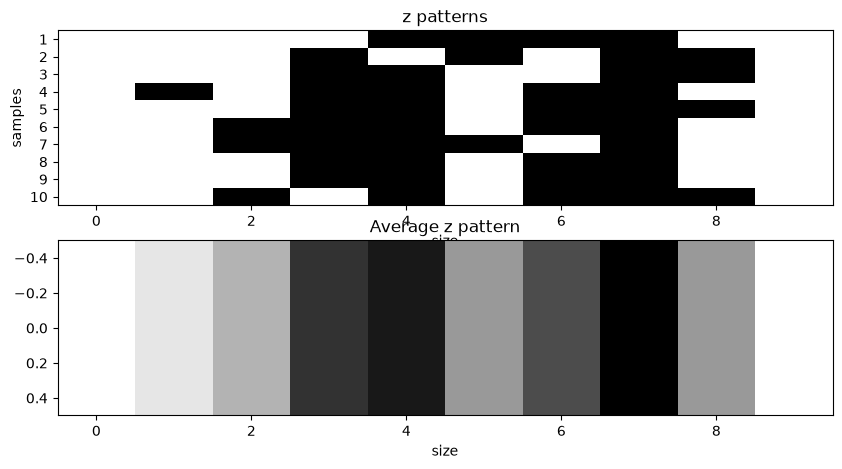

2026-08-20 20:36:23 | data:
[[0. 0. 0. 0. 1. 1. 1. 1. 0. 0.]
 [0. 0. 0. 1. 0. 2. 0. 1. 1. 0.]
 [0. 0. 0. 1. 1. 0. 0. 1. 1. 0.]
 [0. 1. 0. 1. 1. 0. 1. 1. 0. 0.]
 [0. 0. 0. 1. 1. 0. 1. 1. 1. 0.]
 [0. 0. 1. 1. 1. 0. 1. 1. 0. 0.]
 [0. 0. 1. 1. 1. 1. 0. 1. 0. 0.]
 [0. 0. 0. 1. 1. 0. 1. 1. 0. 0.]
 [0. 0. 0. 1. 1. 0. 1. 1. 0. 0.]
 [0. 0. 1. 0. 1. 0. 1. 1. 1. 0.]]


In [17]:
# setup
N = 10
size = 10
heads = 2
variance = 0.1
higher_heads = None
higher_variance = None
isplot = True

data = dg.stimulus_generator(N=N, size=size, heads=heads, variance=variance,
                             higher_heads=higher_heads, higher_variance=higher_variance,
                             plot=isplot, use_uniform=True)

logger(f"data:\n{data}")

### sparse stimuli

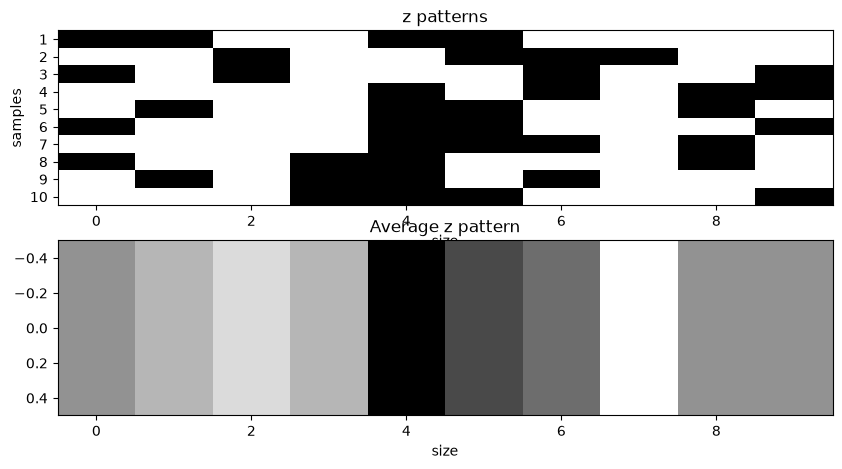

In [8]:
N = 10
K = 4
size = 10
isplot = True

data = dg.sparse_stimulus_generator(N=N, K=K, size=size, plot=isplot)


### gaussian place field activity

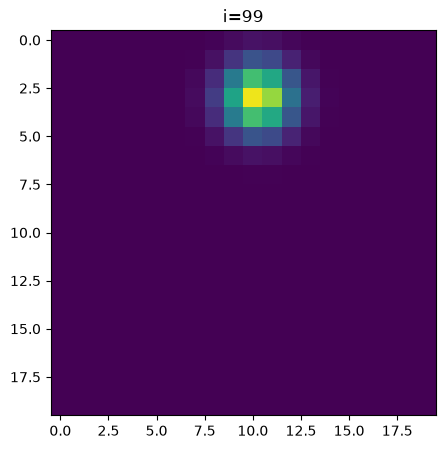

2026-08-20 15:12:51 | 


In [3]:
#data = dg.place_field_activity(N_x=20, N_y=20, sigma=1, xi=5, yi=5)

nx = 20
ny = 20

fig, ax = plt.subplots(figsize=(5, 5))

data = dg.place_field_activity(N_x=nx, N_y=ny, sigma=1, xi=5+nx/2, yi=5+ny/2)
data = dg.gaussian_activity((nx, ny), (5, 5), 3)
im = ax.imshow(data, vmin=0, vmax=1)
for i in range(100):

    clear_output(wait=True)
    ax.set_title(f"{i=}")

    data = dg.gaussian_activity((nx, ny), (7*np.cos(i)+ny/2, 7*np.sin(i)+ny/2), 3)
    #data = dg.place_field_activity(N_x=nx, N_y=ny, sigma=2, xi=7*np.cos(i)+nx/2, yi=7*np.sin(i)+ny/2)
    im.set_data(data)
    display(fig)
    
    plt.pause(0.1)

plt.close(fig)
logger() 


### circular track

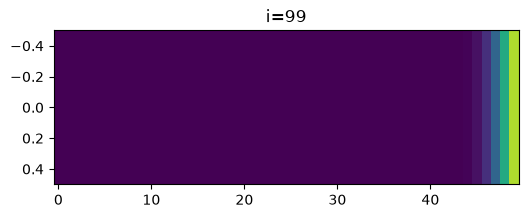

2026-08-20 18:35:59 | 


In [7]:
X = np.arange(50)

fig, ax = plt.subplots(figsize=(6, 2))

data = functions.gaussian_circular_distance(x1=X, x2=0, N=X.max(), sigma=2.).reshape(1, -1)
im = ax.imshow(data, vmin=0, vmax=1, aspect="auto")
for i in range(100):

    clear_output(wait=True)
    ax.set_title(f"{i=}")

    data = functions.gaussian_circular_distance(x1=X, x2=i, N=X.max(), sigma=2.).reshape(1, -1)
    im.set_data(data)
    display(fig)
    
    plt.pause(0.01)

plt.close(fig)
logger() 

### mec-lec observation

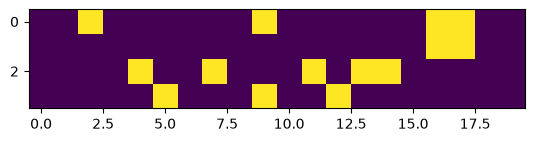

In [53]:
""" test lec pattern generation """
cue_patterns = dg.make_cues(n=4, size=20, fixed=False, p=0.2)

plt.imshow(cue_patterns)
plt.show()

2026-08-20 19:47:13 | 


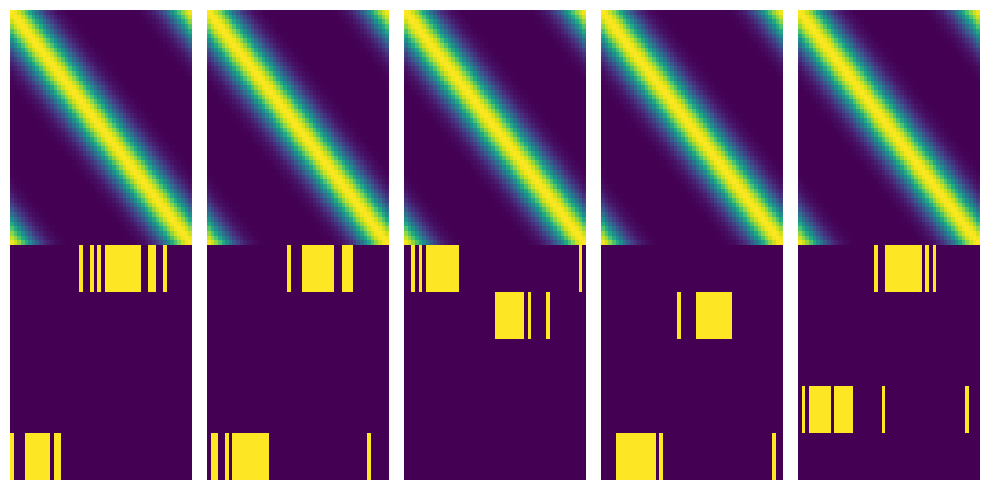

In [69]:
num_cue_patterns = 5
lec_size = 50
num_laps = 5
cue_positions = [10, 30]
cue_sequence = []
for l in range(num_laps):
   cue_sequence += [np.random.choice(list(range(num_cue_patterns)), replace=False, size=len(cue_positions)).tolist()] 

laps = {
    "n": 5,
    "length": 50, 
    "cues_positions": cue_positions, 
    "cues_patterns": dg.make_cues(n=num_cue_patterns, size=lec_size, fixed=True, p=0.2),
    "cues_sequence": cue_sequence
}

data, laps_cus = dg.sparse_stimulus_generator_sensory(laps=laps, mec_sigma=5, lec_sigma=5)

logger()

fig, axs = plt.subplots(1, len(data), figsize=(2*len(data), 5), sharey=True)
fig.set_tight_layout({"h_pad": 0})
for d, ax in zip(data, axs):
    ax.imshow(d.T, aspect="auto")
    ax.axis('off')
plt.show()

# autoencoder

In [ ]:
ae = models.Autoencoder(input_dim=20, encoding_dim=10, K=10, beta=20., use_bias=True):


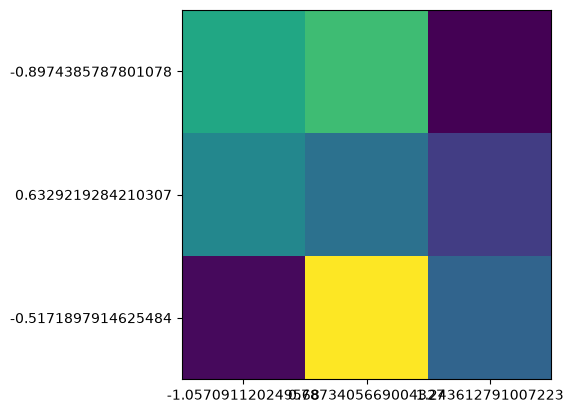

In [30]:
x = np.random.randn(3)
y = np.random.randn(3)
fig, ax = plt.subplots()
ax.imshow(np.random.randn(3, 3))
ax.set_xticks(range(3))
ax.set_xticklabels(x)
ax.set_yticks(range(3))
ax.set_yticklabels(y)
plt.show()